# 00 - Data Audit

Audits the private churn panel (`data/raw/training_clean.xlsx`) to establish the facts that justify the honest evaluation protocol described in `PROJECT_SPEC.md`.

All logic lives in `src/`; this notebook only orchestrates calls, displays results, and writes the verification report. No modeling happens here.

## Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "README.md").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import FIGURES_DIR, OUTPUT_DIR, SEED, set_global_seed
from src.data.loaders import load_churn_panel, month_labels, signal_columns
from src.data.audit import (
    class_balance,
    detect_artifact_months,
    mean_by_month,
    median_trajectory,
    tenure_summary,
    zero_fraction_by_month,
)
from src.visualization.plots import plot_median_trajectory, plot_zero_fraction

AUDIT_FIGURES_DIR = FIGURES_DIR / "data_audit"

set_global_seed()
df = load_churn_panel()
balance = class_balance(df)

print(f"Loaded {balance['n']:,} rows x {df.shape[1]} columns")
print(f"Positives (CHURN=1): {balance['positives']:,} ({balance['positive_rate']:.4%})")

Loaded 99,807 rows x 55 columns
Positives (CHURN=1): 3,804 (3.8114%)


## 1. Leakage signal - USAGE zero-fraction by month

`USAGE` is expected to be strictly positive for an active customer. A spike in the fraction of zero-usage records right before/at the churn label month is a signature of the target leaking into the predictor: the customer has already left by the time `USAGE_N` is recorded, so `USAGE` at `N` (and, to a lesser extent, `N-1`) reflects the churn event rather than predicting it.

,month,churn_zero_frac,nonchurn_zero_frac
0,N-11,0.398528,0.287533
1,N-10,0.391693,0.270710
2,N-9,0.381966,0.257627
3,N-8,0.373028,0.242284
4,N-7,0.380652,0.240076
5,N-6,0.349632,0.208004
6,N-5,0.425342,0.281231
7,N-4,0.291009,0.161214
8,N-3,0.260252,0.104351
9,N-2,0.410358,0.214420


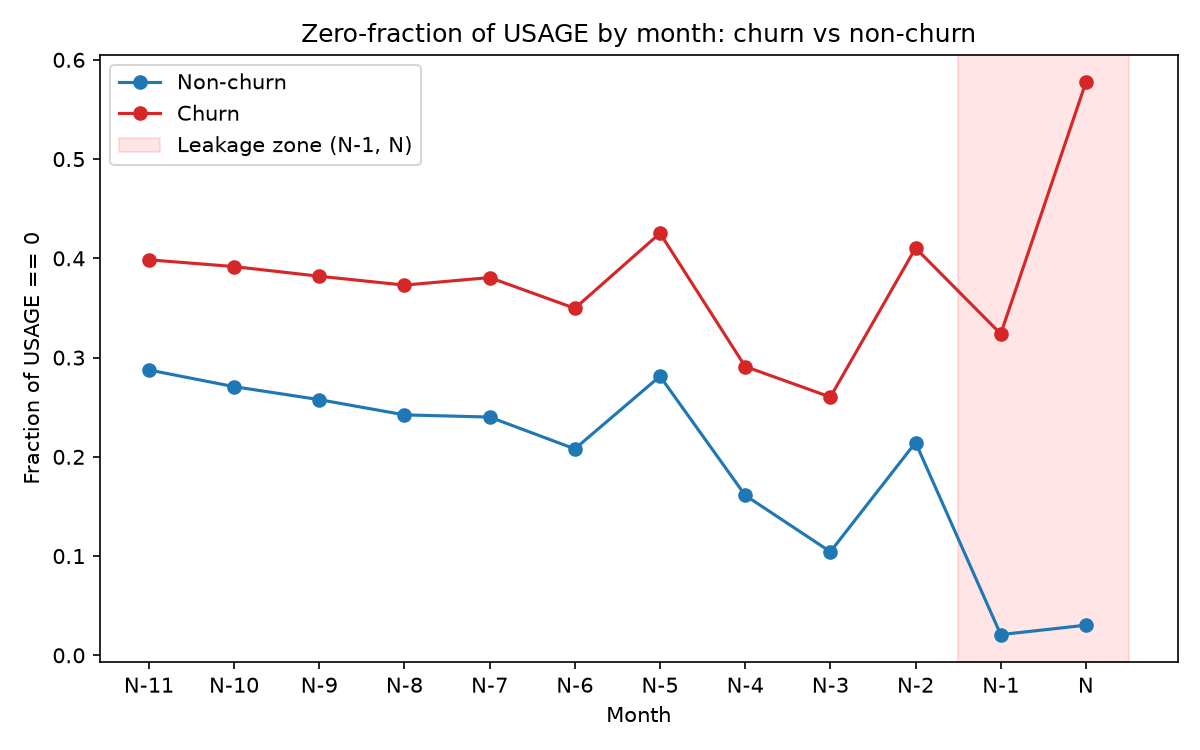

In [2]:
zero_frac = zero_fraction_by_month(df, signal="USAGE")
display(zero_frac)

plot_zero_fraction(zero_frac, "USAGE", AUDIT_FIGURES_DIR / "usage_zero_fraction.png")
display(Image(filename=str(AUDIT_FIGURES_DIR / "usage_zero_fraction.png")))

**Implication:** the collapse in non-zero USAGE at month `N` (and the jump at `N-1`) means these two months record the churn event rather than predict it. The honest modeling window therefore excludes `N` and `N-1`, using only **`N-11 .. N-2`** as predictive features.

## 2. Trajectory - median USAGE by month

Even outside the leakage zone, does USAGE separate the two classes? A persistent gap starting from the earliest month (`N-11`) would indicate churners are a structurally lower-engagement segment, not just customers who happened to drop off usage right before churning.

,month,churn_median,nonchurn_median
0,N-11,2185.865,8731.93
1,N-10,2536.885,9786.93
2,N-9,3107.120,12331.32
3,N-8,3597.835,11513.52
4,N-7,3603.030,13873.26
5,N-6,4148.820,11913.85
6,N-5,41.995,389.96
7,N-4,9083.825,21700.80
8,N-3,11071.490,26958.79
9,N-2,37.045,670.54


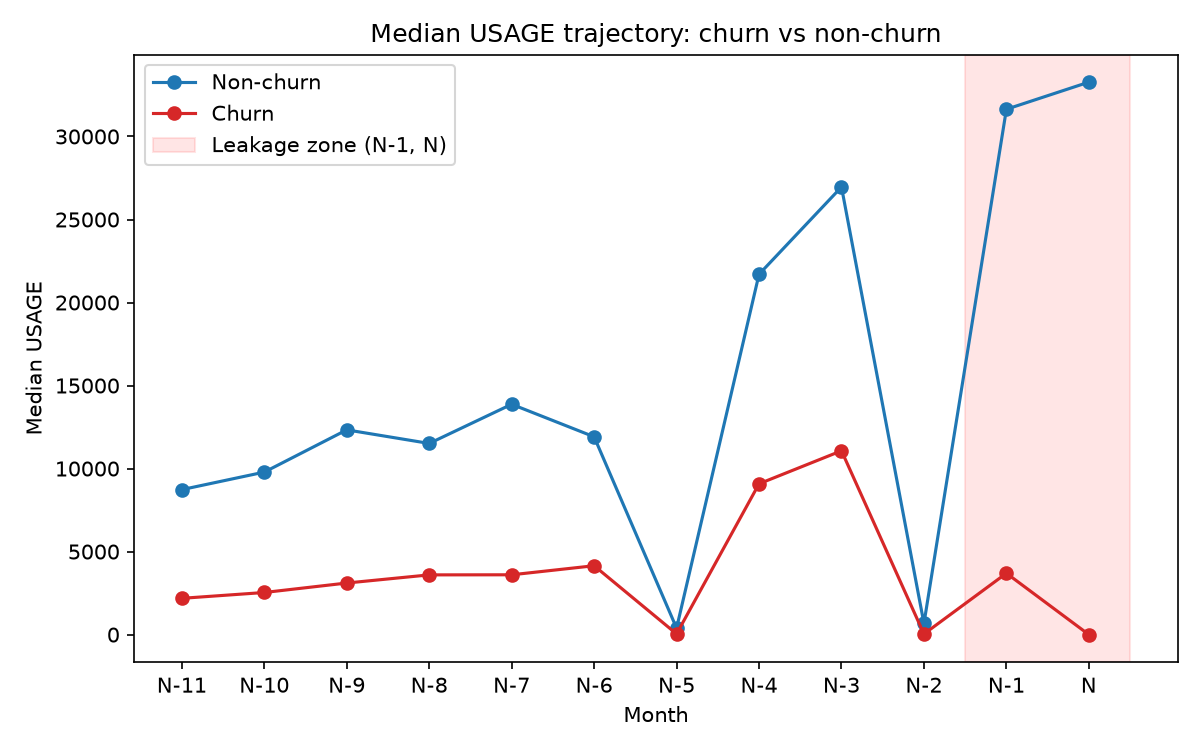

In [3]:
usage_traj = median_trajectory(df, signal="USAGE")
display(usage_traj)

plot_median_trajectory(usage_traj, "USAGE", AUDIT_FIGURES_DIR / "usage_median_trajectory.png")
display(Image(filename=str(AUDIT_FIGURES_DIR / "usage_median_trajectory.png")))

**Implication:** churners show a lower median USAGE than non-churners in every one of the 12 panel months, including `N-11`, the earliest and least leakage-prone month. This supports treating low engagement as a genuine, persistent predictive signal, not an artifact of the leakage window alone.

## 3. Complaints (GGN) - mean by month

`GGN` (gangguan / complaint indicator) is checked for informativeness: does it separate churn from non-churn customers, or is it roughly uniform across the panel?

In [4]:
ggn_mean = mean_by_month(df, signal="GGN")
display(ggn_mean)

,month,churn_mean,nonchurn_mean
0,N-11,0.112250,0.097362
1,N-10,0.100421,0.109486
2,N-9,0.111725,0.110830
3,N-8,0.103575,0.101226
4,N-7,0.093849,0.095549
5,N-6,0.110673,0.113059
6,N-5,0.059148,0.056175
7,N-4,0.090431,0.093872
8,N-3,0.081493,0.082664
9,N-2,0.115668,0.106257


**Implication:** `GGN` means are close between the two classes across most of the panel (within a few hundredths), only diverging materially at month `N`. As a static, mostly-uninformative signal, it is a weak standalone predictor relative to `USAGE`.

## 4. Tenure

Median customer tenure (`UMUR_PLG`), churn vs non-churn.

In [5]:
tenure = tenure_summary(df)
print(f"Median tenure - churn: {tenure['churn_median']:.1f}, non-churn: {tenure['nonchurn_median']:.1f}")

Median tenure - churn: 21.0, non-churn: 27.0


## 5. Artifact months

Flags months whose all-customer median collapses relative to its immediate neighbours (a data artifact rather than a genuine trend), using the default `ratio=0.2` threshold on `USAGE`.

In [6]:
artifact_months = detect_artifact_months(df, signal="USAGE", ratio=0.2)
print(f"Flagged artifact months: {artifact_months}")

months = month_labels()
all_medians = [float(df[col].median()) for col in signal_columns("USAGE")]
artifact_rows = []
for i, month in enumerate(months):
    if month not in artifact_months:
        continue
    neighbours = [all_medians[j] for j in (i - 1, i + 1) if 0 <= j < len(all_medians)]
    neighbour_mean = sum(neighbours) / len(neighbours)
    artifact_rows.append(
        {"month": month, "median": all_medians[i], "neighbour_mean_median": neighbour_mean}
    )
artifact_detail = pd.DataFrame(artifact_rows)
display(artifact_detail)

Flagged artifact months: ['N-5', 'N-2']


,month,median,neighbour_mean_median
0,N-5,373.48,16467.6025
1,N-2,641.47,28541.5050


## 6. Verification report

Computes environment/dataset facts and self-run acceptance checks, then writes `output/00_audit_verification.md`.

In [7]:
import hashlib
import platform

import matplotlib
import numpy as np
import pandas as pd
import sklearn

from src.utils.config import RAW_CHURN_PATH

raw_bytes = RAW_CHURN_PATH.read_bytes()
file_sha256_12 = hashlib.sha256(raw_bytes).hexdigest()[:12]

early_month = "N-11"
zero_at_n = zero_frac.loc[zero_frac["month"] == "N"].iloc[0]
ggn_at_n = ggn_mean.loc[ggn_mean["month"] == "N"].iloc[0]
ggn_at_early = ggn_mean.loc[ggn_mean["month"] == early_month].iloc[0]

usage_median_ok_per_month = (usage_traj["churn_median"] < usage_traj["nonchurn_median"]).all()

checks = [
    {
        "check": "USAGE==0 at N: churn >= 0.50 and non-churn <= 0.06",
        "measured": f"churn={zero_at_n['churn_zero_frac']:.6f}, nonchurn={zero_at_n['nonchurn_zero_frac']:.6f}",
        "target": "churn >= 0.50 AND nonchurn <= 0.06",
        "passed": bool(zero_at_n["churn_zero_frac"] >= 0.50 and zero_at_n["nonchurn_zero_frac"] <= 0.06),
    },
    {
        "check": "median USAGE(churn) < median USAGE(non-churn) for every month",
        "measured": f"holds for {int((usage_traj['churn_median'] < usage_traj['nonchurn_median']).sum())}/12 months",
        "target": "holds for 12/12 months",
        "passed": bool(usage_median_ok_per_month),
    },
    {
        "check": "GGN mean at N: churn < non-churn",
        "measured": f"churn={ggn_at_n['churn_mean']:.6f}, nonchurn={ggn_at_n['nonchurn_mean']:.6f}",
        "target": "churn < nonchurn",
        "passed": bool(ggn_at_n["churn_mean"] < ggn_at_n["nonchurn_mean"]),
    },
    {
        "check": f"GGN mean at {early_month}: |churn - nonchurn| <= 0.03",
        "measured": f"|{ggn_at_early['churn_mean']:.6f} - {ggn_at_early['nonchurn_mean']:.6f}| = {abs(ggn_at_early['churn_mean'] - ggn_at_early['nonchurn_mean']):.6f}",
        "target": "<= 0.03",
        "passed": bool(abs(ggn_at_early["churn_mean"] - ggn_at_early["nonchurn_mean"]) <= 0.03),
    },
    {
        "check": "median tenure(churn) < median tenure(non-churn)",
        "measured": f"churn={tenure['churn_median']:.6f}, nonchurn={tenure['nonchurn_median']:.6f}",
        "target": "churn < nonchurn",
        "passed": bool(tenure["churn_median"] < tenure["nonchurn_median"]),
    },
    {
        "check": "artifact months include N-5 and N-2",
        "measured": f"flagged={artifact_months}",
        "target": "{'N-5', 'N-2'} subset of flagged",
        "passed": bool({"N-5", "N-2"}.issubset(set(artifact_months))),
    },
]

for c in checks:
    c["result"] = "PASS" if c["passed"] else "FAIL"
    print(f"[{c['result']}] {c['check']} | measured: {c['measured']} | target: {c['target']}")

[PASS] USAGE==0 at N: churn >= 0.50 and non-churn <= 0.06 | measured: churn=0.577550, nonchurn=0.030374 | target: churn >= 0.50 AND nonchurn <= 0.06
[PASS] median USAGE(churn) < median USAGE(non-churn) for every month | measured: holds for 12/12 months | target: holds for 12/12 months
[PASS] GGN mean at N: churn < non-churn | measured: churn=0.031020, nonchurn=0.106455 | target: churn < nonchurn
[PASS] GGN mean at N-11: |churn - nonchurn| <= 0.03 | measured: |0.112250 - 0.097362| = 0.014889 | target: <= 0.03
[PASS] median tenure(churn) < median tenure(non-churn) | measured: churn=21.000000, nonchurn=27.000000 | target: churn < nonchurn
[PASS] artifact months include N-5 and N-2 | measured: flagged=['N-5', 'N-2'] | target: {'N-5', 'N-2'} subset of flagged


In [8]:
def _df_to_md_table(frame: pd.DataFrame, float_format: str = "{:.6f}") -> str:
    """Render a small DataFrame as a GitHub-flavored markdown table."""
    header = "| " + " | ".join(frame.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(frame.columns)) + " |"
    lines = [header, sep]
    for _, row in frame.iterrows():
        cells = []
        for value in row:
            cells.append(float_format.format(value) if isinstance(value, float) else str(value))
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)


checks_table = pd.DataFrame(
    [{"check": c["check"], "measured": c["measured"], "target": c["target"], "result": c["result"]} for c in checks]
)

report_lines = [
    "# 00 - Data Audit Verification Report",
    "",
    "## Environment",
    f"- Python: {platform.python_version()}",
    f"- numpy: {np.__version__}",
    f"- pandas: {pd.__version__}",
    f"- scikit-learn: {sklearn.__version__}",
    f"- matplotlib: {matplotlib.__version__}",
    f"- Seed: {SEED}",
    "",
    "## Dataset fingerprint",
    f"- n_rows: {balance['n']:,}",
    f"- n_features: {df.shape[1]}",
    f"- positive_rate: {balance['positive_rate']:.6f}",
    f"- sha256(first 12 chars): {file_sha256_12}",
    "",
    "## Key numbers",
    "",
    "### USAGE == 0 fraction at month N",
    f"- churn: {zero_at_n['churn_zero_frac']:.6f}",
    f"- non-churn: {zero_at_n['nonchurn_zero_frac']:.6f}",
    "",
    "### USAGE median trajectory (12 months, both classes)",
    _df_to_md_table(usage_traj),
    "",
    f"### GGN mean at N vs {early_month} (both classes)",
    f"- N: churn={ggn_at_n['churn_mean']:.6f}, non-churn={ggn_at_n['nonchurn_mean']:.6f}",
    f"- {early_month}: churn={ggn_at_early['churn_mean']:.6f}, non-churn={ggn_at_early['nonchurn_mean']:.6f}",
    "",
    "### Median tenure (UMUR_PLG)",
    f"- churn: {tenure['churn_median']:.6f}",
    f"- non-churn: {tenure['nonchurn_median']:.6f}",
    "",
    "### Flagged artifact months (USAGE, ratio=0.2)",
    _df_to_md_table(artifact_detail) if not artifact_detail.empty else "- none flagged",
    "",
    "## Self-run acceptance checks",
    _df_to_md_table(checks_table, float_format="{}"),
    "",
]
report_text = "\n".join(report_lines)

report_path = OUTPUT_DIR / "00_audit_verification.md"
report_path.write_text(report_text, encoding="utf-8")
print(report_text)

# 00 - Data Audit Verification Report

## Environment
- Python: 3.12.3
- numpy: 2.4.6
- pandas: 3.0.3
- scikit-learn: 1.9.0
- matplotlib: 3.11.0
- Seed: 42

## Dataset fingerprint
- n_rows: 99,807
- n_features: 55
- positive_rate: 0.038114
- sha256(first 12 chars): c04f3a55aa4f

## Key numbers

### USAGE == 0 fraction at month N
- churn: 0.577550
- non-churn: 0.030374

### USAGE median trajectory (12 months, both classes)
| month | churn_median | nonchurn_median |
| --- | --- | --- |
| N-11 | 2185.865000 | 8731.930000 |
| N-10 | 2536.885000 | 9786.930000 |
| N-9 | 3107.120000 | 12331.320000 |
| N-8 | 3597.835000 | 11513.520000 |
| N-7 | 3603.030000 | 13873.260000 |
| N-6 | 4148.820000 | 11913.850000 |
| N-5 | 41.995000 | 389.960000 |
| N-4 | 9083.825000 | 21700.800000 |
| N-3 | 11071.490000 | 26958.790000 |
| N-2 | 37.045000 | 670.540000 |
| N-1 | 3696.580000 | 31640.170000 |
| N | 0.000000 | 33273.680000 |

### GGN mean at N vs N-11 (both classes)
- N: churn=0.031020, non-churn=0.1064